1. Познакомьтесь с данными.
2. Осуществите предобработку данных.
    - 2.1 Приведите заголовки к удобному виду.
    - 2.2 Проверьте типы данных.
    - 2.3 Обработайте пропуски.
    - 2.4 Проверьте наличие дубликатов.
    - 2.5 Исключите нулевые значения в выручке для дальнейшего исследования. 
3. Исследовательский анализ данных:
     - 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.
     - 3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.
     - 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.
     - 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы.
     - 3 .5  Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета:
     https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat
     - 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

Каждый пункт исследования сопроводите выводами.


In [2]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st
from scipy.stats import mannwhitneyu

**Читаем файл и знакомимся с данными. Для удобства сразу меняем заголовки на строчные буквы)**

In [4]:
data = pd.read_csv('air_data.csv', delimiter = ";")
data.rename(columns=str.lower, inplace=True)

In [5]:
data

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE
...,...,...,...,...,...,...,...,...,...
49995,2022-06-11 00:00:00,2022-06-22 00:00:00,CHD,480,MOW,OMS,ВВЛ,NaN,ONLINE
49996,2022-06-06 00:00:00,2022-06-20 00:00:00,AD,270,LED,MOW,ВВЛ,NaN,OFFLINE
49997,2022-06-26 00:00:00,2022-06-29 00:00:00,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE
49998,2022-06-26 00:00:00,2022-06-28 00:00:00,AD,270,KZN,MOW,ВВЛ,NaN,OFFLINE


### Предобработка данных: (внутри исправлены столбец ffp_flag и дубликаты)
1. Проверка типа данных
2. Проверяем наличие пропусков
3. Ищем дубликаты
4. Исключаем нулевые значения в выручке для дальнейшего исследования

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   issue_date         50000 non-null  object
 1   flight_date_loc    50000 non-null  object
 2   pax_type           50000 non-null  object
 3   revenue_amount     50000 non-null  int64 
 4   orig_city_code     49998 non-null  object
 5   dest_city_code     49999 non-null  object
 6   route_flight_type  50000 non-null  object
 7   ffp_flag           19398 non-null  object
 8   sale_type          50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB


**При проверке типов данных можно заметить что столбцы, содержащие информацию о дате покупки билета и дате совершения полета читаются как строки. Меняем на тип данных для дат** 

In [9]:
data['issue_date'] = pd.to_datetime(data['issue_date'])
data['flight_date_loc'] = pd.to_datetime(data['flight_date_loc'])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   issue_date         50000 non-null  datetime64[ns]
 1   flight_date_loc    50000 non-null  datetime64[ns]
 2   pax_type           50000 non-null  object        
 3   revenue_amount     50000 non-null  int64         
 4   orig_city_code     49998 non-null  object        
 5   dest_city_code     49999 non-null  object        
 6   route_flight_type  50000 non-null  object        
 7   ffp_flag           19398 non-null  object        
 8   sale_type          50000 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 3.4+ MB


In [11]:
data.isna().sum()

issue_date               0
flight_date_loc          0
pax_type                 0
revenue_amount           0
orig_city_code           2
dest_city_code           1
route_flight_type        0
ffp_flag             30602
sale_type                0
dtype: int64

**Исправлен столбец ffp_flag**

In [13]:
#data['ffp_flag'] = data['ffp_flag'].fillna('отсутствует')
data['ffp_flag'] = data['ffp_flag'].fillna(False)
data['ffp_flag'] = data['ffp_flag'].astype(bool)

In [14]:
data['ffp_flag'].unique()

array([False,  True])

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   issue_date         50000 non-null  datetime64[ns]
 1   flight_date_loc    50000 non-null  datetime64[ns]
 2   pax_type           50000 non-null  object        
 3   revenue_amount     50000 non-null  int64         
 4   orig_city_code     49998 non-null  object        
 5   dest_city_code     49999 non-null  object        
 6   route_flight_type  50000 non-null  object        
 7   ffp_flag           50000 non-null  bool          
 8   sale_type          50000 non-null  object        
dtypes: bool(1), datetime64[ns](2), int64(1), object(5)
memory usage: 3.1+ MB


In [16]:
data = data.dropna(subset=['orig_city_code']).reset_index(drop=True)  
data = data.dropna(subset=['dest_city_code']).reset_index(drop=True)  

In [17]:
data.isna().sum()

issue_date           0
flight_date_loc      0
pax_type             0
revenue_amount       0
orig_city_code       0
dest_city_code       0
route_flight_type    0
ffp_flag             0
sale_type            0
dtype: int64

***ВЫВОД ПО ПРОПУСКАМ:***
- В столбце с наличием программы лояльности пропусков оказалось очень много. ~~Т.к. она или есть или нет, заменяем все пропуски на "отсутствует"~~ Заменяем тип данных стобца на bool, где все пропуски (отсутствие программый лояльности) - False, а ее наличие - True
- Столбцы, содержащие информацию о городах отправления и прибытия в сумме имеют 3 пропуска. На фоне всех данных это количество незначительно и можно предположить, что эти строки были добавлены ошибочно. Их разумно удалить и забыть

In [19]:
data.head(5)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,False,OFFLINE
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,True,ONLINE
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,False,ONLINE
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,True,OFFLINE


**Исправлены дубликаты**

In [21]:
data.duplicated().sum()

169

In [22]:
data = data.drop_duplicates()

***ВЫВОД  ПО ДУБЛИКАТАМ:*** 
- Явные дубликаты существуют, но т.к. в датафрейме нет никаких индивидуальных данных (например айди покупателя или точное время покупки билета), ~~эти дубликаты ими и не являются. Явные дубликаты содержат информацию о билетах, купленных в один день на одинаковый рейс, так что их мы не удаляем.~~ Каждая строка - уникальная покупка, удаляем дубликаты
- Т.к. индивидуальные данные отсутсвуют, то и неявных дубликатов не существует

In [24]:
data['revenue_amount'].unique()

array([ 200,  610,  390,  190,  250,   70,  490,  280,  360,  380,  210,
          0,  370, 1090,  470,  450,  300,  180,  570,  430,  350,  130,
        230,  290,  160,  420,  690,  340,  310,  520,  440,  400,  930,
        240,  170,  270,  150,  560,  260,  220,  680, 1820,  410,  630,
        550,  840,  110,  140,  100,  640,  720,  460,  120,  540,  330,
       1030,   40,  320,  530,  820,   50,  480,  960,  500,  760, 2000,
        810,  670,  790,  950,  590,  600,  510,  710,  830, 1140,  620,
        750,  770, 1200, 1110,  970, 1180,  740,  650,  730,  660,  800,
        860,  890,  920,  580,  700,  880,  850,  940, 1070,  910, 1690,
        870, 1930,  780, 2990, 1780,  980, 1620,   60,   90, 1150, 1160,
       1040,  900, 1760, 1320,   80, 1020, 2270,  990, 1260, 1080, 1940,
       1060, 1280, 1190, 1470, 1810, 1520, 1010, 1000, 1360, 1340, 1220,
       1980, 1530, 1330, 2300, 1450, 1630, 1510, 2060, 1590, 1120, 1500,
       1860, 1250, 1050, 1660, 1460, 1610, 2050, 11

In [25]:
data.drop(data[data['revenue_amount'] == 0].index, inplace=True)

Все нулевые значения выручки были удалены

### Исследовательский анализ данных: 

- 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.
- 3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.
- 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.
- 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы.
- 3 .5  Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета: https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat
- 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

#### 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.

##### Отчет о динамике продаж(выручке) + линейный график

In [31]:
data.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE


In [32]:
dynamic_amount = data.groupby('issue_date')['revenue_amount'].sum()
data['month'] = data['issue_date'].dt.strftime('%Y-%m')
dynamic_months = data.groupby('month')['revenue_amount'].sum()
print(dynamic_amount)
print(dynamic_months)

issue_date
2021-10-01    60310
2021-10-02    33100
2021-10-03    34320
2021-10-04    58190
2021-10-05    60800
              ...  
2022-09-26    39520
2022-09-27    48350
2022-09-28    44860
2022-09-29    27460
2022-09-30    25980
Name: revenue_amount, Length: 365, dtype: int64
month
2021-10    1327840
2021-11    1851260
2021-12    1757250
2022-01    1352390
2022-02    1347770
2022-03    1826430
2022-04    2032570
2022-05    1713360
2022-06    1614500
2022-07    2638430
2022-08    2471260
2022-09    1669310
Name: revenue_amount, dtype: int64


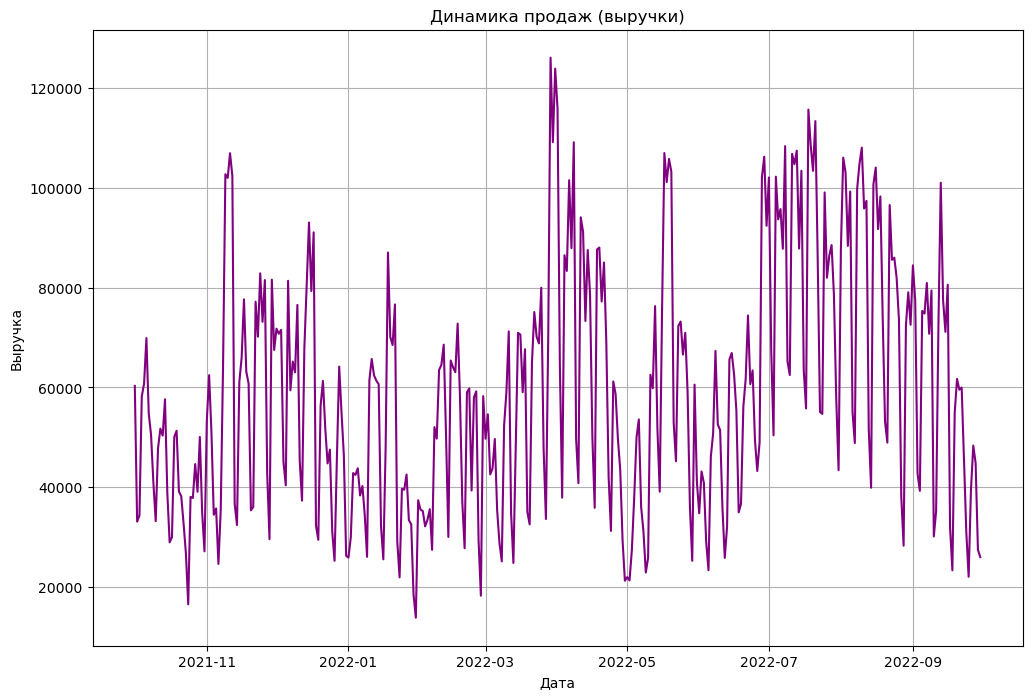

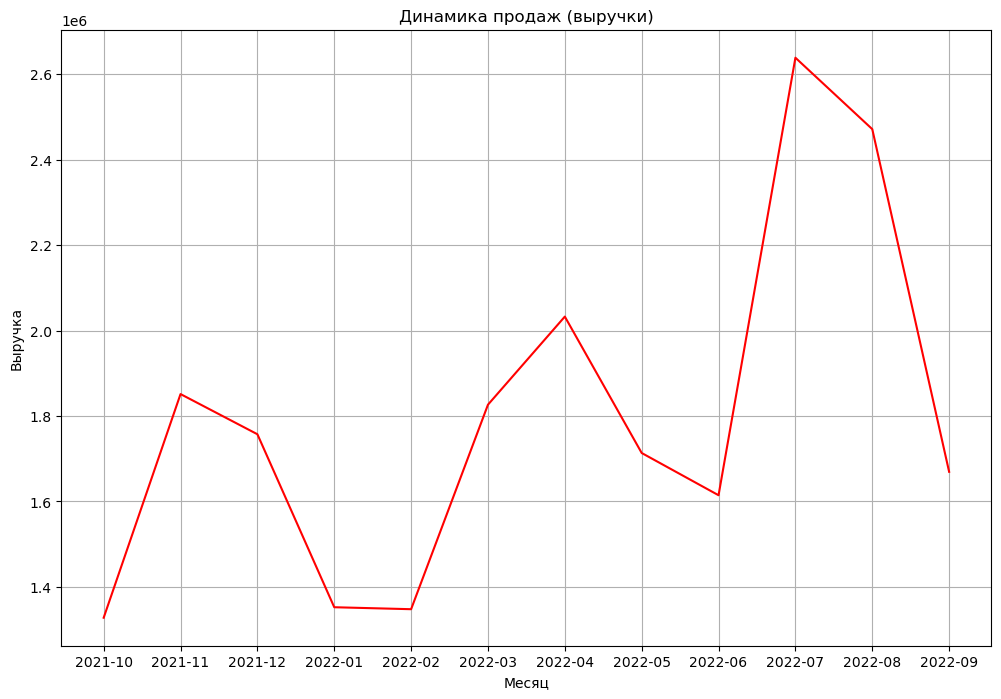

In [33]:
plt.figure(figsize=(12, 8))
plt.plot(dynamic_amount, c='purple')
plt.title('Динамика продаж (выручки)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.grid()
plt.show()

plt.figure(figsize=(12, 8))
plt.plot(dynamic_months, c='r')
plt.title('Динамика продаж (выручки)')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
plt.show()

***ВЫВОД:*** **Линейный график по дням не очень нагляден, поэтому было принято решение построить график по месяцам. Создав новый столбец с месяцем и годом, можно построить наглядный график. По ним видно, что выручка нестабильна как по дням, так и по месяцам. При дальнейшей детализации также будет использована информация по месяцам**

##### Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE + линейные графики

- детализация по ffp_flag

In [37]:
amount_by_month_ffp = data.groupby(['month', 'ffp_flag'])['revenue_amount'].sum().unstack()
amount_by_month_ffp

ffp_flag,False,True
month,,
2021-10,825810,502030
2021-11,1116160,735100
2021-12,1036240,721010
2022-01,813850,538540
2022-02,848530,499240
2022-03,1025070,801360
2022-04,1267690,764880
2022-05,1063840,649520
2022-06,1023580,590920


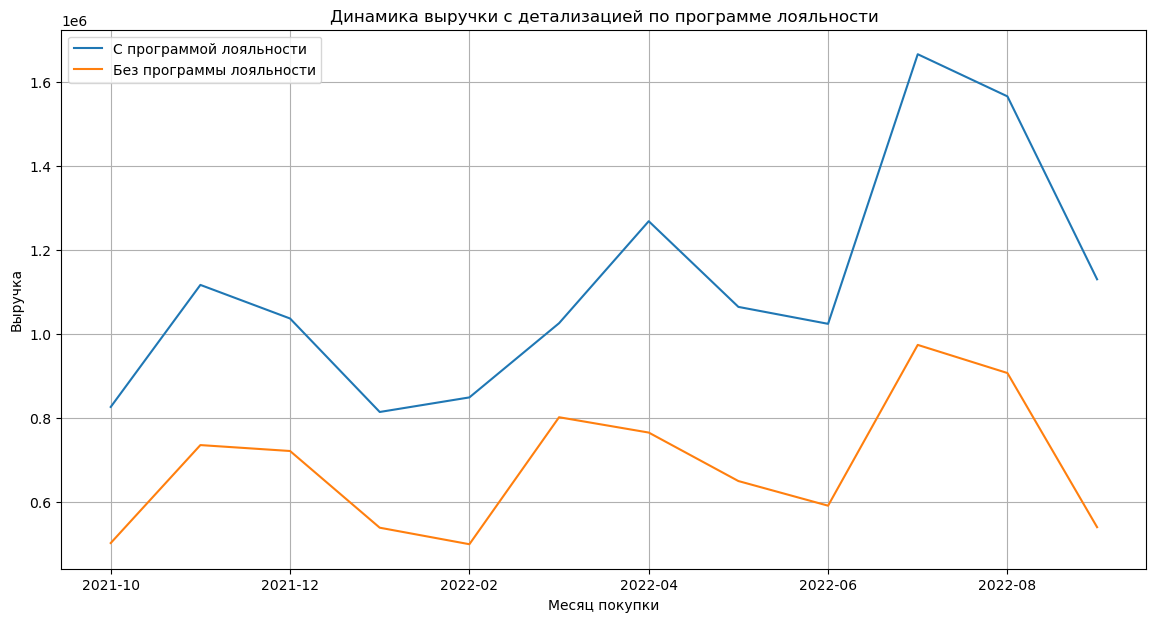

In [38]:
amount_by_month_ffp.plot(figsize=(14, 7))
plt.title('Динамика выручки с детализацией по программе лояльности')
plt.xlabel('Месяц покупки')
plt.ylabel('Выручка')
plt.legend(['С программой лояльности', 'Без программы лояльности'])
plt.grid(True)
plt.show()

***ВЫВОД:*** **По графику видно, что каждый месяц выручка с билетов, купленных без программы, больше, чем с ней**

- детализация по route_flight_type

In [41]:
amount_by_month_route = data.groupby(['month', 'route_flight_type'])['revenue_amount'].sum().unstack()
amount_by_month_route

route_flight_type,ВВЛ,МВЛ
month,,
2021-10,1039020,288820
2021-11,1528990,322270
2021-12,1452480,304770
2022-01,1152790,199600
2022-02,1173370,174400
2022-03,1789040,37390
2022-04,1926430,106140
2022-05,1635180,78180
2022-06,1523810,90690


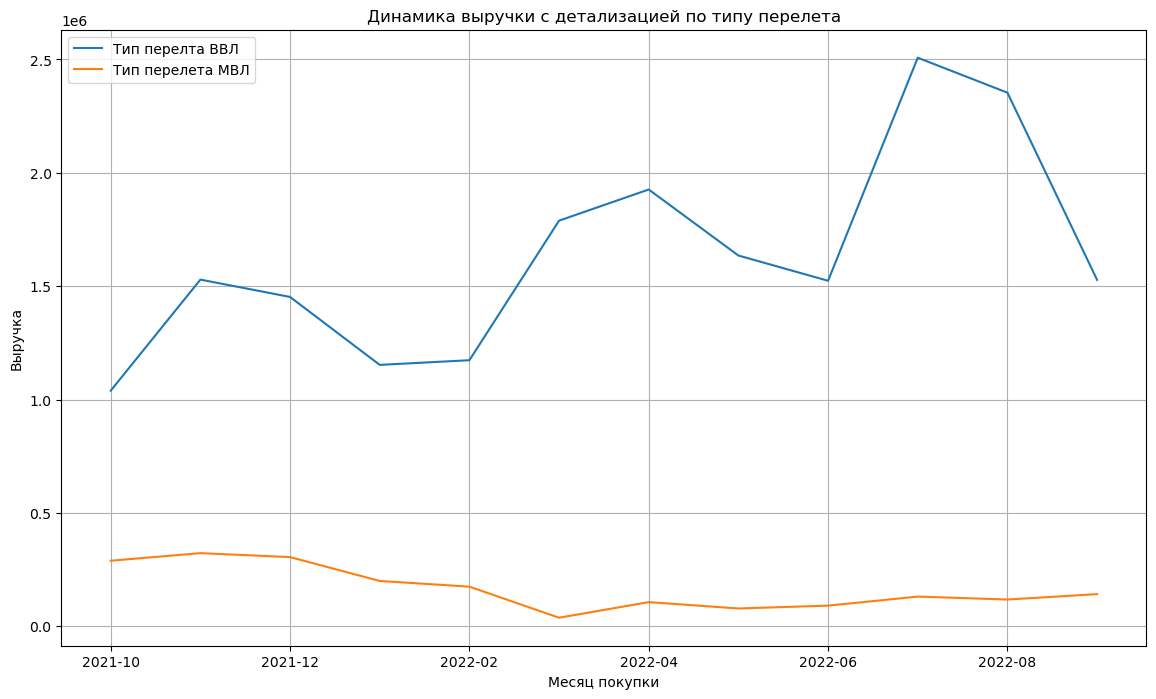

In [42]:
amount_by_month_route.plot(figsize=(14, 8))
plt.title('Динамика выручки с детализацией по типу перелета')
plt.xlabel('Месяц покупки')
plt.ylabel('Выручка')
plt.legend(['Тип перелта ВВЛ', 'Тип перелета МВЛ'])
plt.grid(True)
plt.show()

***ВЫВОД:*** **По графику видно, что с типом перелета ВВЛ было гараздо больше выручки каждый месяц, чем с типом перелета МВЛ, можно сделать вывод, что пассажиры больше предпочитают ВВЛ**

- детализация по sale_type

In [45]:
amount_by_month_sale = data.groupby(['month', 'sale_type'])['revenue_amount'].sum().unstack()
amount_by_month_sale

sale_type,OFFLINE,ONLINE
month,,
2021-10,649640,678200
2021-11,901140,950120
2021-12,853050,904200
2022-01,623900,728490
2022-02,670260,677510
2022-03,796020,1030410
2022-04,1035090,997480
2022-05,743570,969790
2022-06,753650,860850


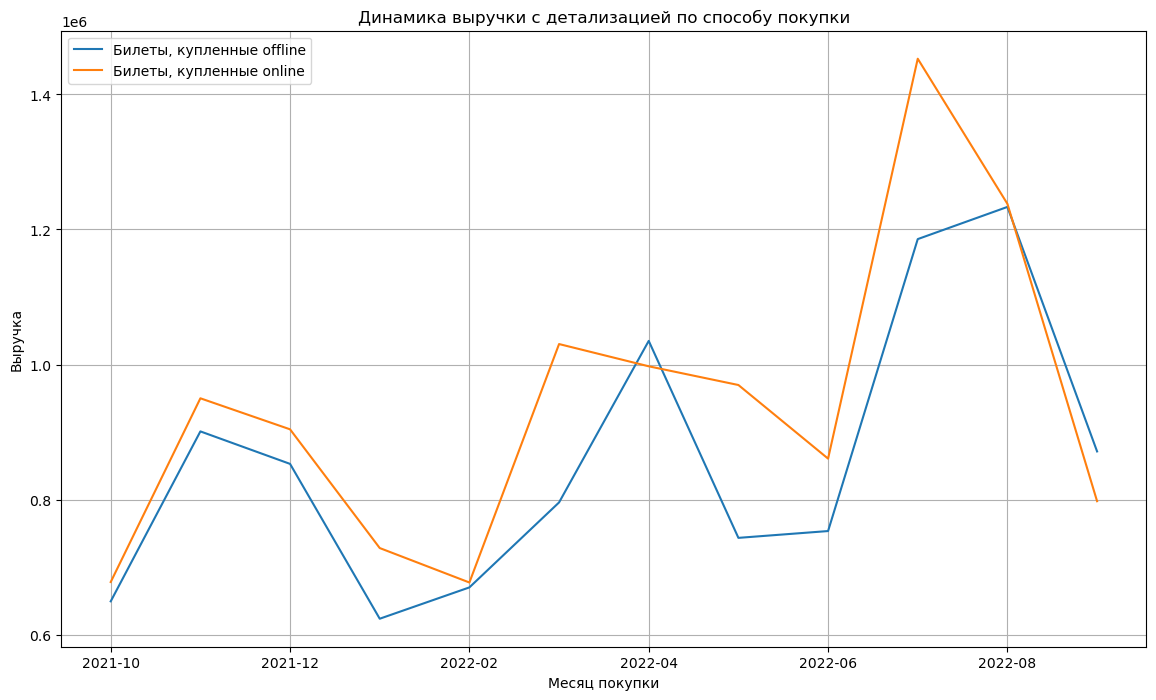

In [46]:
amount_by_month_sale.plot(figsize=(14, 8))
plt.title('Динамика выручки с детализацией по способу покупки')
plt.xlabel('Месяц покупки')
plt.ylabel('Выручка')
plt.legend(['Билеты, купленные offline', 'Билеты, купленные online'])
plt.grid(True)
plt.show()

***ВЫВОД:*** **По графику можно увидеть, что значения выручки с билетов, купленных онлайн и оффлайн, очень близки, однако лидирующую позицию все же занимают online билеты**

##### Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. (для простоты наблюдения будут построены столбчатые диаграммы)

In [49]:
data.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12


- отчет по выручке по типам пассажиров

In [51]:
amount_by_pax_type = data.groupby('pax_type')['revenue_amount'].sum()
amount_by_pax_type

pax_type
AD     20259210
CHD     1333430
INF        9730
Name: revenue_amount, dtype: int64

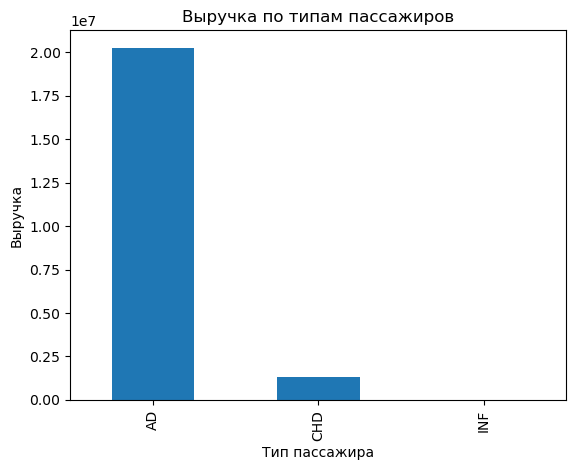

In [52]:
amount_by_pax_type.plot(kind='bar')
plt.title('Выручка по типам пассажиров')
plt.xlabel('Тип пассажира')
plt.ylabel('Выручка')
plt.show()

***ВЫВОД:*** **По графику отчетливо видно, что большая часть выручки приходится на взрослых пассажиров. На детей в разы меньше, а значение "неизвестных" пассажиров незначительно на фоне всех данных. Можно сделать вывод, что для детей существует множество скидок на перелеты, что и является низкой выручкой с детских билетов**

- отчет по выручке по типам перелета

In [55]:
amount_by_route_flight_type = data.groupby('route_flight_type')['revenue_amount'].sum()
amount_by_route_flight_type

route_flight_type
ВВЛ    19610480
МВЛ     1991890
Name: revenue_amount, dtype: int64

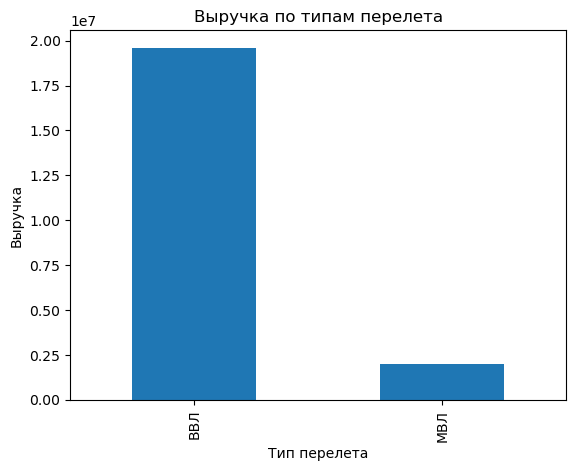

In [56]:
amount_by_route_flight_type.plot(kind='bar')
plt.title('Выручка по типам перелета')
plt.xlabel('Тип перелета')
plt.ylabel('Выручка')
plt.show()

***ВЫВОД:*** **Раннее мы уже выяснили, что большинство пассажирей предпочитают тип перелета - ВВЛ, как по месяцам, так и в общем**

- отчет по выручке по способам покупки

In [59]:
amount_by_sale_type = data.groupby('sale_type')['revenue_amount'].sum()
amount_by_sale_type

sale_type
OFFLINE    10316900
ONLINE     11285470
Name: revenue_amount, dtype: int64

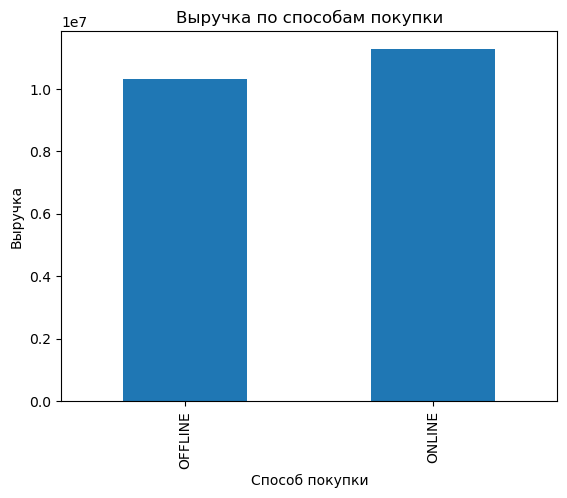

In [60]:
amount_by_sale_type.plot(kind='bar')
plt.title('Выручка по способам покупки')
plt.xlabel('Способ покупки')
plt.ylabel('Выручка')
plt.show()

***ВЫВОД:*** **Тут такая же ситуцация, как с типом перелетов. На графики с месяцами, мы уже увидели, что разница между способами покупки незначительна, но все-таки онлайн способ предпочитают больше на протяжении всего периода**

- отчет по выручке по программам лояльности

In [63]:
amount_by_ffp_flag = data.groupby('ffp_flag')['revenue_amount'].sum()
amount_by_ffp_flag

ffp_flag
False    13379980
True      8222390
Name: revenue_amount, dtype: int64

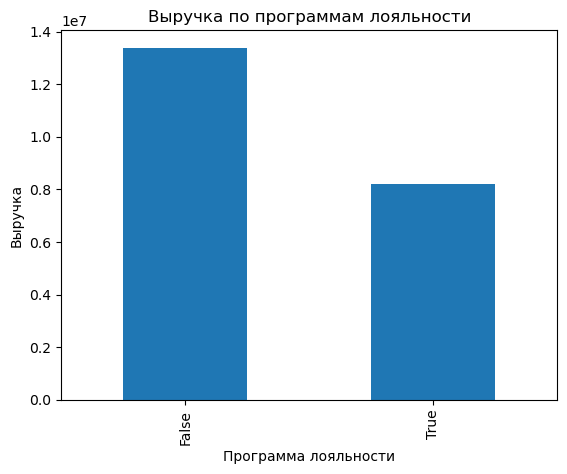

In [64]:
amount_by_ffp_flag.plot(kind='bar')
plt.title('Выручка по программам лояльности')
plt.xlabel('Программа лояльности')
plt.ylabel('Выручка')
plt.show()

***ВЫВОД:*** **Такая же ситуация. В общем случае выручка также больше без программы лояльности, чем с ней, как и по месяцам**

#### 3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.

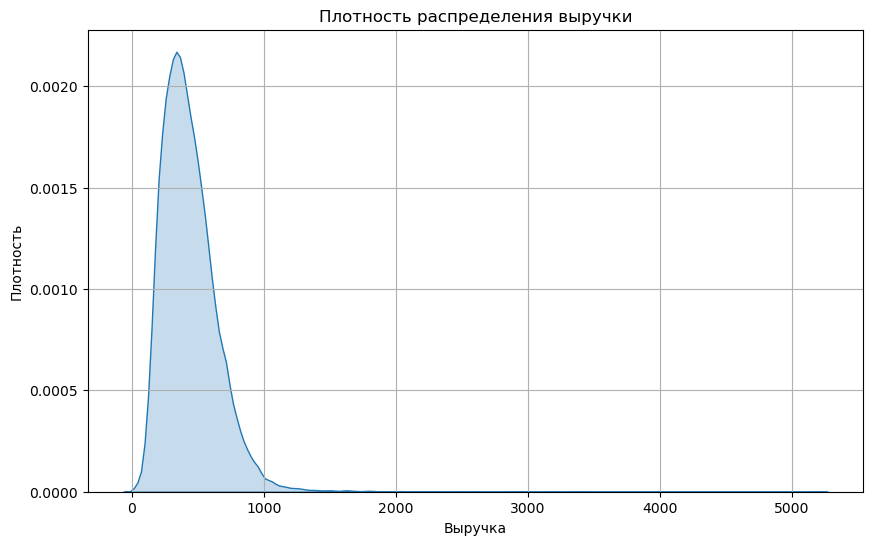

In [67]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data = data['revenue_amount'], fill =True)
plt.title('Плотность распределения выручки')
plt.grid()
plt.xlabel("Выручка")
plt.ylabel("Плотность")
plt.show()

Text(0, 0.5, 'Частота')

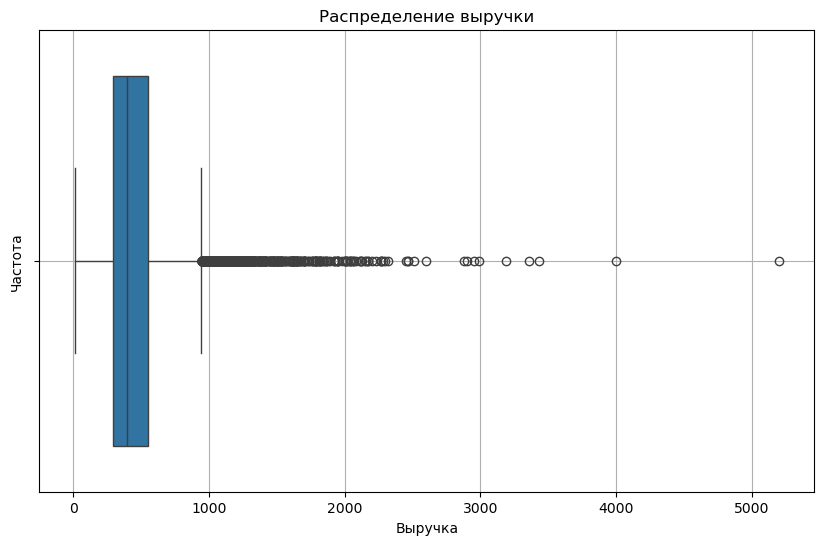

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = data['revenue_amount'], orient='h')
plt.title('Распределение выручки')
plt.grid()
plt.xlabel('Выручка')
plt.ylabel('Частота')

In [69]:
Q1 = data['revenue_amount'].quantile(0.25)
Q3 = data['revenue_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)

-100.0 940.0


In [70]:
outliers = data[(data['revenue_amount'] < lower_bound) + (data['revenue_amount'] > upper_bound)]
print(f"Количество выбросов: {len(outliers)}")

Количество выбросов: 987


In [71]:
outliers_fraction = len(outliers) / len(data)
print(f"Доля выбросов: {outliers_fraction*100}")

Доля выбросов: 1.9995137960374376


In [72]:
filtered_data = data[(data['revenue_amount'] >= lower_bound) & (data['revenue_amount'] <= upper_bound)]
print(f"Количество оставшихся записей: {len(filtered_data)}")

Количество оставшихся записей: 48375


In [73]:
newQ3 = data['revenue_amount'].quantile(0.99)
new_upper_bound = newQ3 + 1.5 * IQR

In [74]:
new_outliers = data[data['revenue_amount'] > new_upper_bound]
print(f"Количество выбросов: {len(new_outliers)}")

Количество выбросов: 155


In [75]:
data = data[data['revenue_amount'] <= new_upper_bound]

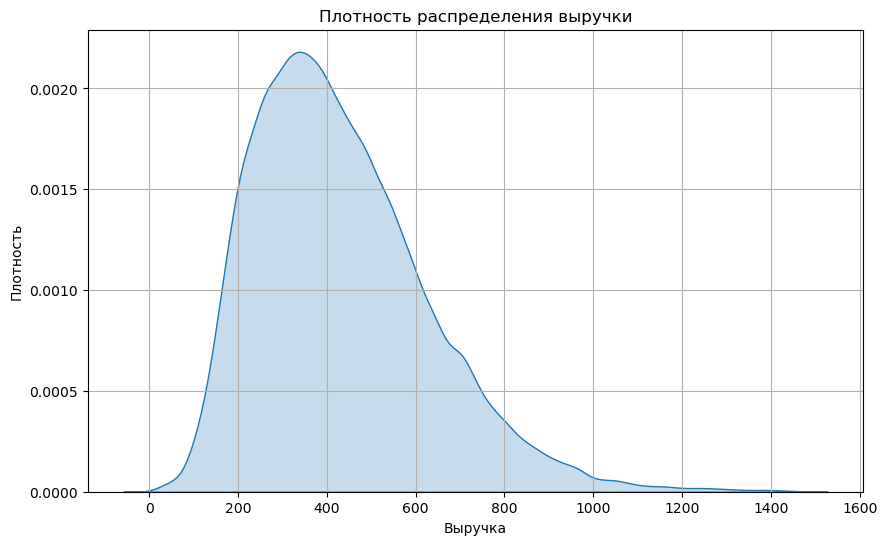

In [76]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data = data['revenue_amount'], fill =True)
plt.title('Плотность распределения выручки')
plt.grid()
plt.xlabel("Выручка")
plt.ylabel("Плотность")
plt.show()

Text(0, 0.5, 'Частота')

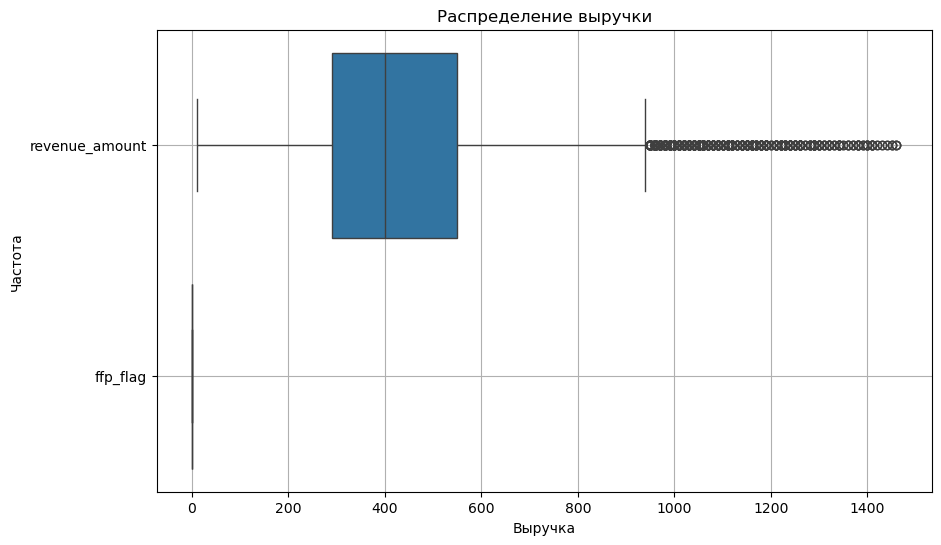

In [77]:
plt.figure(figsize=(10, 6))
sns.boxplot(data, orient='h')
plt.title('Распределение выручки')
plt.grid()
plt.xlabel('Выручка')
plt.ylabel('Частота')

***ВЫВОД:*** **При исследовании выручки с помощью boxplot и вычислений границ выбросов было найдено 1000 выбросов, в рамках наших данных это всего 2%, но мною было принято решение удалить самые далекие выбросы, находящиеся за 0.99 квантилем (т.к. ниже Q1 выбросов не было, то и нижнюю границу трогать не пришлось). В итоге было удалено 157 выброса**

#### 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.

##### Иследуем сезонность продаж  (внутри исправлен график)

In [81]:
dynamic_months = data.groupby('month')['revenue_amount'].count()
dynamic_months

month
2021-10    3606
2021-11    5155
2021-12    4553
2022-01    3578
2022-02    3443
2022-03    4313
2022-04    3965
2022-05    3619
2022-06    3347
2022-07    5243
2022-08    4766
2022-09    3619
Name: revenue_amount, dtype: int64

- При просмотре результатов можно сделать вывод, что самая большие продажи были в ноябре 2021 года, а самая низкие в июне 2022 года
- Для построения графика и дальнейшего анализа будет удобно создать новый столбец с сезоном 

In [83]:
def seasons(n):
    if n in ['2021-10','2021-11','2022-09']:
        return 'Autumn'
    elif n in ['2021-12','2022-01','2022-02']:
        return 'Winter'
    elif n in ['2022-03','2022-04','2022-05']:
        return 'Spring'
    else:
        return 'Summer'
data['season'] = data['month'].apply(seasons)

In [84]:
data.head(5)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,season
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12,Winter
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,False,OFFLINE,2021-12,Winter
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,True,ONLINE,2021-11,Autumn
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,False,ONLINE,2021-12,Winter
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,True,OFFLINE,2021-12,Winter


In [85]:
amount_by_season = data.groupby('season')['revenue_amount'].count()
amount_by_season

season
Autumn    12380
Spring    11897
Summer    13356
Winter    11574
Name: revenue_amount, dtype: int64

**Исправлен график**

In [87]:
#plt.figure(figsize=(14, 8))
#plt.plot(amount_by_season, color = 'purple')
#plt.title('Продажи по сезону')
#plt.xlabel('Cезон')
#plt.ylabel('Продажи')
#plt.grid(True)
#plt.show()

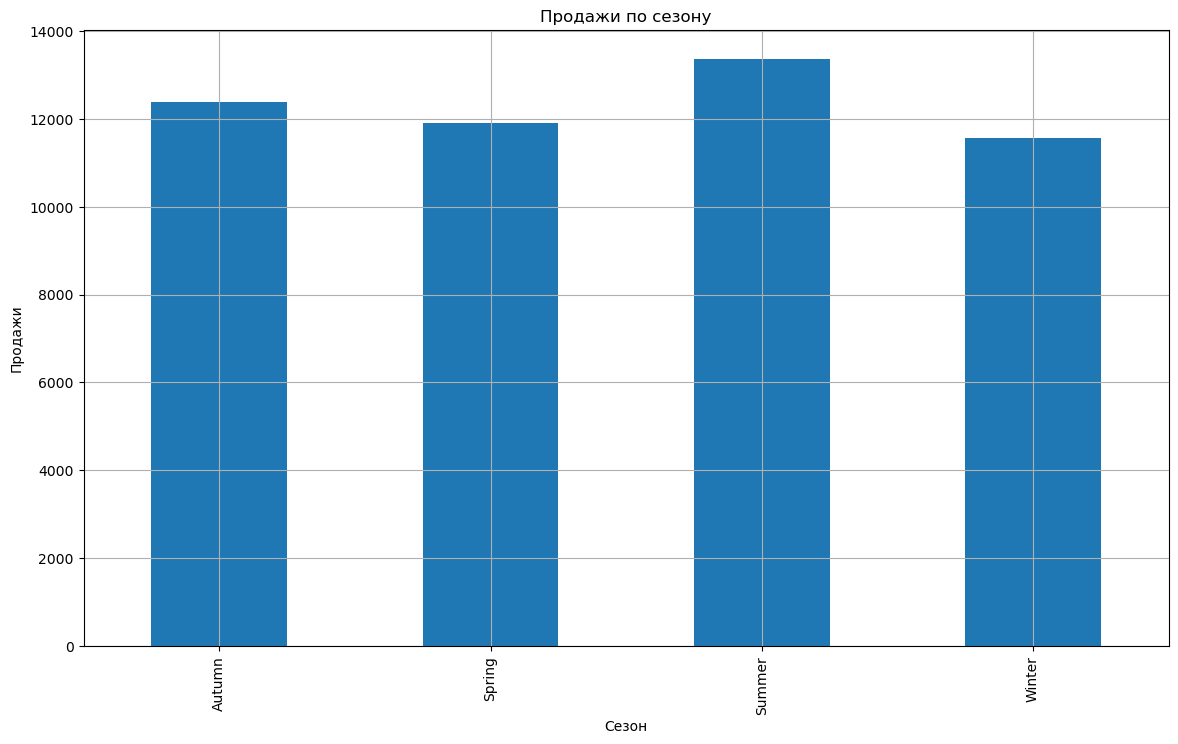

In [88]:
plt.figure(figsize=(14, 8))
amount_by_season.plot(kind='bar')
plt.title('Продажи по сезону')
plt.xlabel('Cезон')
plt.ylabel('Продажи')
plt.grid(True)
plt.show()

***ВЫВОД:*** **Заметим, что самое большое количество продаж приходится на лето, а самое маленькое количество на зиму. Что неудивительно, лето сезон отпусков и каникул**

##### Проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается

- Гипотеза H0: выручки от продаж осенью и зимой равны
- Ггипотеза H1: выручка от продаж осенью больше выручки от продаж зимой

In [92]:
data.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,season
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12,Winter


In [93]:
autumn_amount = data[data['season'] == 'Autumn']['revenue_amount']
winter_amount = data[data['season'] == 'Winter']['revenue_amount']

In [94]:
print(f'Осенью было продано {autumn_amount.count()} билетов.')
print(f'Зимой было продано {winter_amount.count()} билетов.')

Осенью было продано 12380 билетов.
Зимой было продано 11574 билетов.


- Построим гистограммы

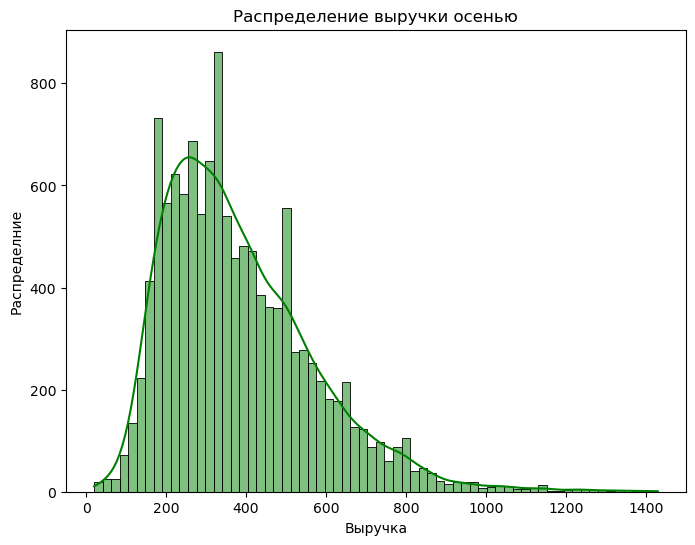

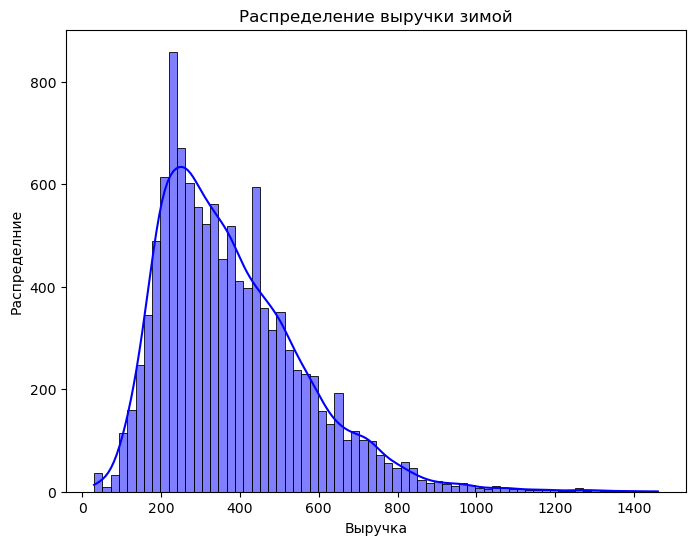

In [96]:
plt.figure(figsize=(8, 6))
sns.histplot(autumn_amount, kde=True, color='green')
plt.title('Распределение выручки осенью')
plt.xlabel('Выручка')
plt.ylabel('Распределние')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(winter_amount, kde = True, color='blue')
plt.title('Распределение выручки зимой')
plt.xlabel('Выручка')
plt.ylabel('Распределние')
plt.show()

- Построим Q-Q plots

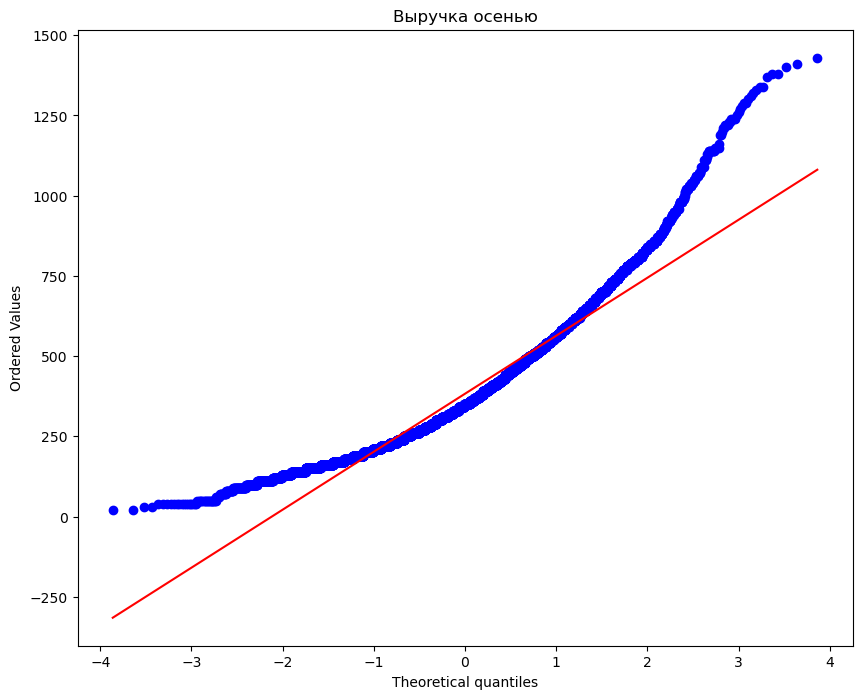

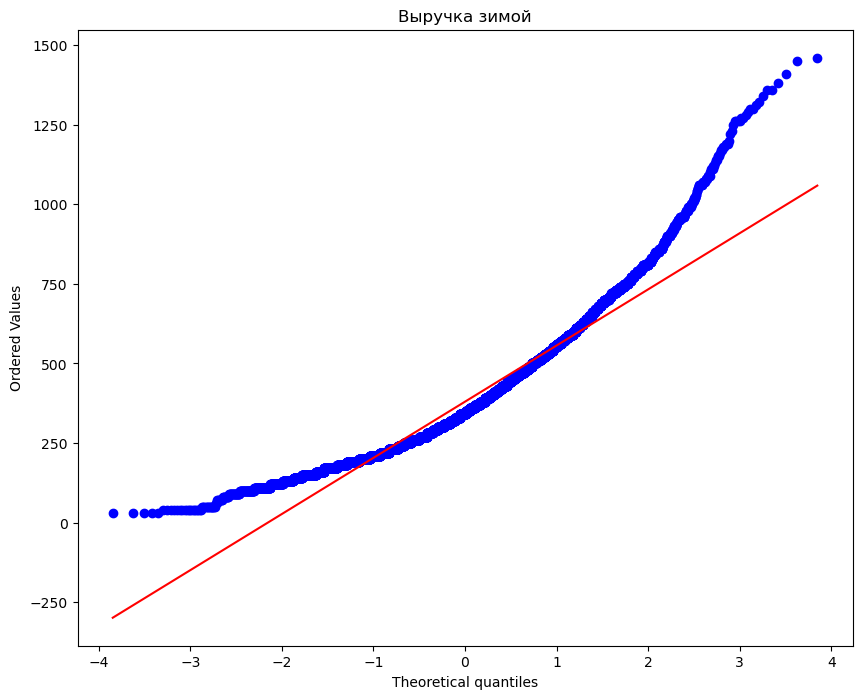

In [98]:
plt.figure(figsize = (10, 8))
st.probplot(autumn_amount, dist='norm', plot=plt)
plt.title('Выручка осенью')
plt.show()

plt.figure(figsize = (10, 8))
st.probplot(winter_amount, dist='norm', plot=plt)
plt.title('Выручка зимой')
plt.show()

**Т.к. у нас довольно большая выборка, то воспользоваться тестом Шапиро-уилка мы не можем. На помощь приходит тест Манна-Уитни**

In [100]:
alpha = 0.05

results = st.mannwhitneyu(autumn_amount, winter_amount)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу. Различие между выручками зимой и осенью значимо') 
else:
    print('Не удалось отвергнуть нулевую гипотезу. Нет осснований утверждать, что выручки осенью и зимой отличаются') 

p-value: 0.39391092742877354
Не удалось отвергнуть нулевую гипотезу. Нет осснований утверждать, что выручки осенью и зимой отличаются


***ВЫВОД:*** **Проверили гипотезу о том, что выручки от продаж осенью и зимой отличаются. QQ-plot помог увидеть, что выборки не имеют нормальное распределние. Использовали критерий Манна-Уитни для проверки различий в выручках осенью и зимой и выяснили, что не удалось отвергнуть нулевую гипотезу. Нет осснований утверждать, что выручки осенью и зимой отличаются**

##### Исследуйте выручку и число продаж по месяцам, проверьте корреляцию

In [103]:
data['sos'] = (data['issue_date'].dt.month + 2) % 12

In [104]:
inf_by_months = data.groupby(data['sos']).agg(amount_sum=('revenue_amount', 'sum'), amount_count=('revenue_amount', 'count')).reset_index()
inf_by_months['month'] = data['month']
inf_by_months

,sos,amount_sum,amount_count,month
0,0,1311370,3606,2021-12
1,1,1817360,5155,2021-12
2,2,1733500,4553,2021-11
3,3,1332620,3578,2021-12
4,4,1329630,3443,2021-12
5,5,1801600,4313,2021-11
6,6,2015840,3965,2021-12
7,7,1710130,3619,2021-11
8,8,1602410,3347,2021-12
9,9,2611190,5243,2021-11


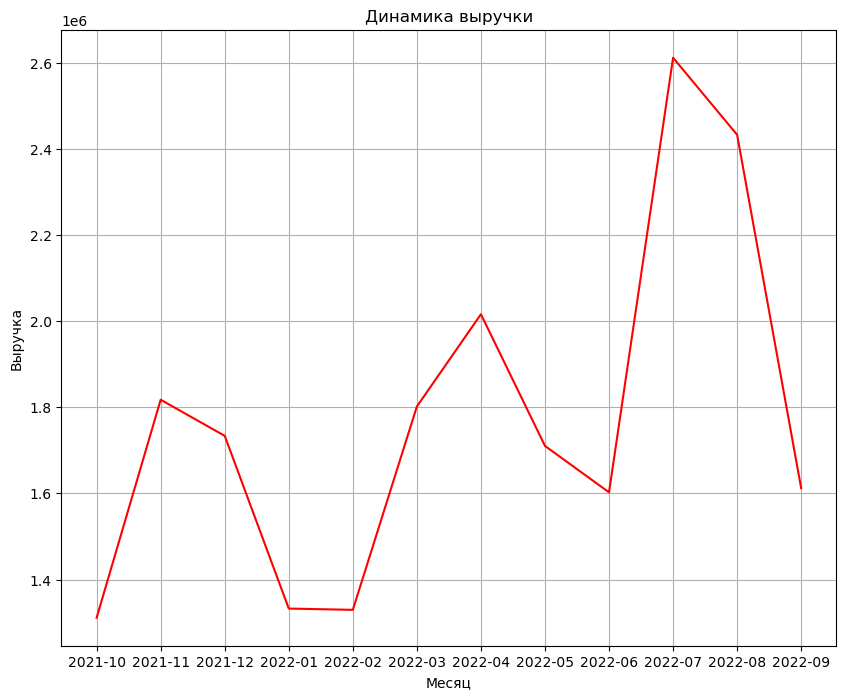

In [105]:
amount_sum = data.groupby('month')['revenue_amount'].sum()
plt.figure(figsize=(10, 8))
plt.plot(amount_sum, c='r')
plt.title('Динамика выручки')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
plt.show()

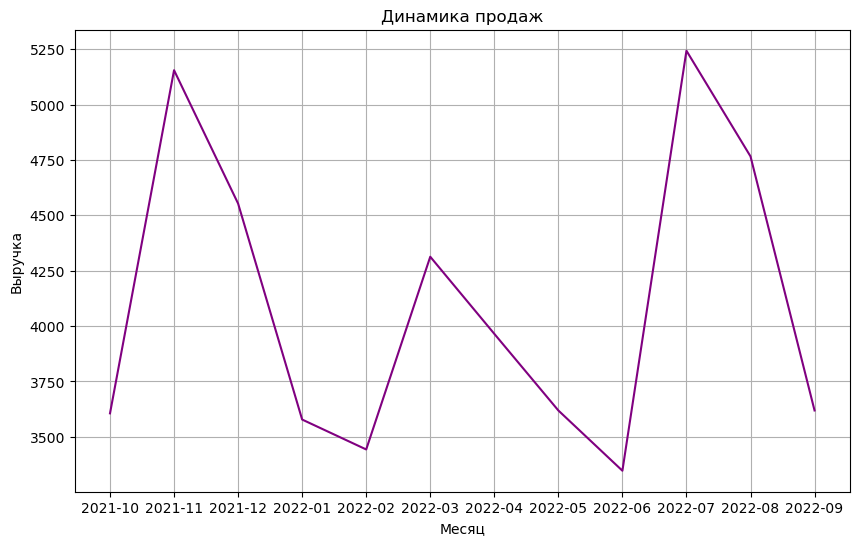

In [106]:
amount_count = data.groupby('month')['revenue_amount'].count()
plt.figure(figsize=(10, 6))
plt.plot(amount_count, c='purple')
plt.title('Динамика продаж')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
plt.show()

- Проверяем корреляцию

In [108]:
correlation_for_sum = inf_by_months['sos'].corr(inf_by_months['amount_sum'])
correlation_for_count = inf_by_months['sos'].corr(inf_by_months['amount_count'])
print(f"Корреляция между датой продажи и количеством продаж: {correlation_for_sum}")
print(f"Корреляция между датой продажи и количеством продаж: {correlation_for_count}")

Корреляция между датой продажи и количеством продаж: 0.5418839350269582
Корреляция между датой продажи и количеством продаж: 0.009193046230875693


***ВЫВОД:***
- Корреляция 0.5398 между месяцем и выручкой указывает на умеренную положительную линейную связь между этими двумя переменными.
- Корреляция 0.0068 между месяцем и количеством продаж указывает на практически полное отсутствие линейной зависимости между этими двумя переменными. Связь слабая.

#### 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы. (внутри испралвен тест на ANOVA)

In [111]:
data

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,season,sos
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12,Winter,2
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,False,OFFLINE,2021-12,Winter,2
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,True,ONLINE,2021-11,Autumn,1
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,False,ONLINE,2021-12,Winter,2
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,True,OFFLINE,2021-12,Winter,2
...,...,...,...,...,...,...,...,...,...,...,...,...
49992,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,False,ONLINE,2022-06,Summer,8
49993,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,False,OFFLINE,2022-06,Summer,8
49994,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,True,ONLINE,2022-06,Summer,8
49995,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,False,OFFLINE,2022-06,Summer,8


In [112]:
data['days_before_the_flight'] = (data['flight_date_loc'] - data['issue_date']).dt.days
data['days_before_the_flight'].unique()

array([ 35,   3,  37,  28,  46,  34,  40,  39,  49,  45,  26,  42,   8,
        48,  38,  36,  20,   4,  24,  25,  55,  54,  41,  60,  10,  32,
        47,  53,  12,  52,  33,  22,  17,  30,   7,  31,  56,  27,  23,
        15,  43,  29,  51,  57,  63,  50,  21,   6,  19,   5,   1,  44,
         2,  18,  13,   9,  16,  14,  11,   0,  75,  74,  58, 123,  62,
       118, 297, 110, 109, 251, 291, 293, 265, 304, 264, 282, 242, 262,
       268, 243, 128, 244, 230, 235, 245, 228, 249, 229, 221, 186, 231,
       248, 208, 215, 202, 198, 222, 199, 169, 195, 216, 173, 207, 179,
       196, 220, 212, 214, 209, 200, 217, 201, 203, 226, 187, 178, 192,
       177, 204, 189, 180, 175, 190, 205, 184, 163, 181, 174,  94,  67,
       191, 172, 156, 188, 136, 183, 171, 182,  86, 134, 170, 159, 176,
       194,  68, 165, 168, 121, 105, 137, 152, 143, 154, 116, 114, 151,
       139, 125, 160, 157, 162, 146, 145, 153,  66, 140, 148, 149, 166,
       135, 150, 147, 141, 124, 133, 126, 131, 144, 115, 138, 11

In [113]:
data['days_before_the_flight'].max()

317

**Разброс в разнице покупки билета и полетом оказался большим, т.к. кто-то покупает билет в день полета, а кто-то почти за год до полета (не уверена что такое вообще возможно...:0). Разделим на 4 группы: покупка билетов за 14 дней, за два месяца, за пол года и больше. И добавим столбец с этой информацией**

In [115]:
groups = [(data['days_before_the_flight'] <= 14), 
          (data['days_before_the_flight'] > 14) & (data['days_before_the_flight'] <= 60), 
          (data['days_before_the_flight'] > 60) & (data['days_before_the_flight'] <= 180),
          (data['days_before_the_flight'] > 180)]
days = ['0-14 дней', '14-60 дней', '60-180 дней', '>180 дней']
data['groups'] = np.select(groups, days)
data.sample(5)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,season,sos,days_before_the_flight,groups
20259,2022-09-06,2022-09-07,AD,470,MOW,KEJ,ВВЛ,True,ONLINE,2022-09,Autumn,11,1,0-14 дней
28455,2022-08-09,2022-08-19,AD,1380,AER,OVB,ВВЛ,True,OFFLINE,2022-08,Summer,10,10,0-14 дней
3632,2022-02-18,2022-03-03,CHD,490,MOW,RGK,ВВЛ,False,ONLINE,2022-02,Winter,4,13,0-14 дней
41826,2022-03-21,2022-03-22,AD,290,UFA,MOW,ВВЛ,False,ONLINE,2022-03,Spring,5,1,0-14 дней
322,2021-10-30,2021-11-25,CHD,420,MOW,IKT,ВВЛ,False,ONLINE,2021-10,Autumn,0,26,14-60 дней


In [116]:
prosmotr = data.groupby('groups')['revenue_amount'].count().reset_index()
prosmotr

,groups,revenue_amount
0,0-14 дней,30200
1,14-60 дней,14754
2,60-180 дней,3976
3,>180 дней,277


**Проверим сколько проданных билетов попало в каждую группу. Конечно, они получились не равнозначными, но мне кажется это оптимальные границы, которые отражают за сколько дней до полета люди предпочитают покупать билеты**

**Проверим гипотезу**
- Н0: Выручка от продажи билетов не зависит от количества дней до полета
- Н1: Выручка от продажи билетов зависит от количества дней до полета

In [119]:
group_1 = data[data['groups'] == '0-14 дней']['revenue_amount']
group_2 = data[data['groups'] == '14-60 дней']['revenue_amount']
group_3 = data[data['groups'] == '60-180 дней']['revenue_amount']
group_4 = data[data['groups'] == '>180 дней']['revenue_amount']

**Решила, что Q-Q plot лучше убрать и построить боксплоты, где мы модем увидеть, что медианные значения примерно находятся на одном уровне. Тут мы убеждаемся, еще до ANOVA теста, что различия в средних значениях недостаточны для признания их статистически значимыми**

In [121]:
#построим Q-Q plot
#plt.figure(figsize = (6, 3))
#st.probplot(group_1, dist='norm', plot=plt)
#plt.title('Выручка c проданных билетов за 14 дней')
#plt.show()

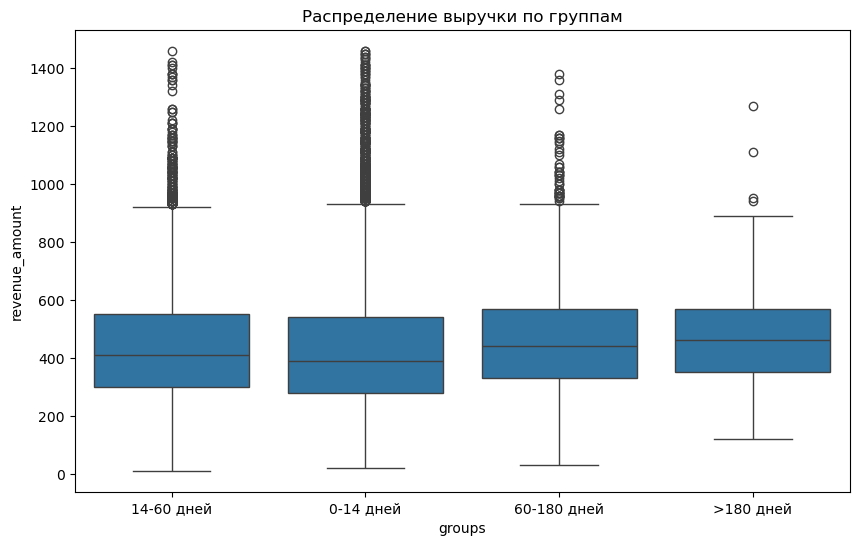

In [122]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='groups', y='revenue_amount', data=data)
plt.title('Распределение выручки по группам')
plt.show()

In [123]:
prosmotr1 = data.groupby('groups')['revenue_amount'].mean().reset_index()
prosmotr1

,groups,revenue_amount
0,0-14 дней,429.164901
1,14-60 дней,434.023993
2,60-180 дней,457.069920
3,>180 дней,462.960289


In [124]:
#alpha = 0.05

#for group in data['groups'].unique():
    #stat, result = st.shapiro(data[data['groups'] == group]['revenue_amount'])
    #print(f'Группа: {group}: \np-value: {result}')
    #if result < alpha:
        #print('Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения\n')
    #else:
        #print('Не получилось отвергнуть нулевую гипотезу. Выборка имеет нормальное распределение')

**Проведем ANOVA тест**

In [126]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [127]:
model = ols('revenue_amount ~ (groups)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Вывод таблицы ANOVA
print(anova_table)

                sum_sq       df         F        PR(>F)
groups    3.011612e+06      3.0  25.90762  9.735835e-17
Residual  1.906522e+09  49203.0       NaN           NaN


***ВЫВОД:*** **Т.к p-значение (PR(>F)) больше уровня значимости (0.05), то нулевую гипотезу мы принимаем, что означает отсутствие статистически значимых различий между средними значениями групп. (Кстати, изначально, получается, даже вывод пошел не туда, ведь в матрице корреляций ниже мы увидели, что количество дней между покупкой и полетом не имеет сильного влияния. Куда-то не туда меня занесло в этой пункте, ночное помутнение:)))**

~~***ВЫВОД:*** **Все три сравнения не имеют нормального распределния, а значит выручка напрямую зависит от того, как заранее покупают билет. Чем больше дней с момента покупки билета до полета, тем больше покупатель платит за него, соответсетвенно чкм меньше дней до полета, тем меньше стоимость билета**~~

#### 3 .5 Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета: https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat

##### Загружаем файл (внутри изменено аэропорт-аэропорт на город-город)

In [132]:
url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat'

In [133]:
airports = pd.read_csv(url, 
                         names=['Airport Name', 'Location', 'Country', 'IATA_Code', 'ICAO_Code', 'Latitude', 'Longitude', 'Altitude', 'Timezone', 
                                'DST', 'Timezone Region', 'Type', 'Source'])
airports.head(3)

,Airport Name,Location,Country,IATA_Code,ICAO_Code,Latitude,Longitude,Altitude,Timezone,DST,Timezone Region,Type,Source
1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.08169,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.20708,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.82679,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports


In [134]:
new_data = data.merge(airports, left_on='orig_city_code', right_on='IATA_Code', how='left')
new_data.rename(columns={'Location': 'orig_city_name'}, inplace=True)
new_data = new_data.merge(airports, left_on='dest_city_code', right_on='IATA_Code', how='left')
new_data.rename(columns={'Location': 'dest_city_name'}, inplace=True)
new_data.head(7)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,...,IATA_Code_y,ICAO_Code_y,Latitude_y,Longitude_y,Altitude_y,Timezone_y,DST_y,Timezone Region_y,Type_y,Source_y
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12,...,KGD,UMKK,54.889999,20.592600,42.0,2,N,Europe/Kaliningrad,airport,OurAirports
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,False,OFFLINE,2021-12,...,OVB,UNNT,55.012600,82.650703,365.0,7,N,Asia/Krasnoyarsk,airport,OurAirports
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,True,ONLINE,2021-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,False,ONLINE,2021-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,True,OFFLINE,2021-12,...,KRR,URKK,45.034698,39.170502,118.0,3,N,Europe/Moscow,airport,OurAirports
5,2021-11-29,2022-01-14,AD,250,MOW,DUS,МВЛ,False,ONLINE,2021-11,...,DUS,EDDL,51.289501,6.766780,147.0,1,E,Europe/Berlin,airport,OurAirports
6,2021-12-03,2022-01-06,AD,200,MOW,PEE,ВВЛ,True,ONLINE,2021-12,...,PEE,USPP,57.914501,56.021198,404.0,5,N,Asia/Yekaterinburg,airport,OurAirports


**Можно заметить, что у нас осталось куча пропущенных значений, добавим данные еще раз, но теперь по ICAO_Code**

In [136]:
new_data = pd.merge(new_data, airports[['ICAO_Code', 'Location']], left_on='orig_city_code', right_on='ICAO_Code', how='left', suffixes=('', '_icao'))
new_data = pd.merge(new_data, airports[['ICAO_Code', 'Location']], left_on='dest_city_code', right_on='ICAO_Code', how='left', suffixes=('', '_icao'))

In [137]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49207 entries, 0 to 49206
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   issue_date              49207 non-null  datetime64[ns]
 1   flight_date_loc         49207 non-null  datetime64[ns]
 2   pax_type                49207 non-null  object        
 3   revenue_amount          49207 non-null  int64         
 4   orig_city_code          49207 non-null  object        
 5   dest_city_code          49207 non-null  object        
 6   route_flight_type       49207 non-null  object        
 7   ffp_flag                49207 non-null  bool          
 8   sale_type               49207 non-null  object        
 9   month                   49207 non-null  object        
 10  season                  49207 non-null  object        
 11  sos                     49207 non-null  int32         
 12  days_before_the_flight  49207 non-null  int64 

##### Работа с пропусками и создание датафрейма для поиска топ-10 

**Все столбцы нам не нужны, оставляем только те, которые нужны для определения топ-10**

In [140]:
right_data = new_data[['orig_city_code','orig_city_name','dest_city_code', 'revenue_amount', 'dest_city_name','route_flight_type','IATA_Code_x',
                       'IATA_Code_y','ICAO_Code_x','ICAO_Code_y']]
right_data

,orig_city_code,orig_city_name,dest_city_code,revenue_amount,dest_city_name,route_flight_type,IATA_Code_x,IATA_Code_y,ICAO_Code_x,ICAO_Code_y
0,MOW,NaN,KGD,200,Kaliningrad,ВВЛ,NaN,KGD,NaN,UMKK
1,UUS,Yuzhno-sakhalinsk,OVB,610,Novosibirsk,ВВЛ,UUS,OVB,UHSS,UNNT
2,KGD,Kaliningrad,MOW,390,NaN,ВВЛ,KGD,NaN,UMKK,NaN
3,VOZ,Voronezh,MOW,190,NaN,ВВЛ,VOZ,NaN,UUOO,NaN
4,MOW,NaN,KRR,190,Krasnodar,ВВЛ,NaN,KRR,NaN,URKK
...,...,...,...,...,...,...,...,...,...,...
49202,MOW,NaN,OMS,480,Omsk,ВВЛ,NaN,OMS,NaN,UNOO
49203,LED,St. Petersburg,MOW,270,NaN,ВВЛ,LED,NaN,ULLI,NaN
49204,MOW,NaN,KZN,230,Kazan,ВВЛ,NaN,KZN,NaN,UWKD
49205,KZN,Kazan,MOW,270,NaN,ВВЛ,KZN,NaN,UWKD,NaN


In [141]:
right_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49207 entries, 0 to 49206
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   orig_city_code     49207 non-null  object
 1   orig_city_name     33083 non-null  object
 2   dest_city_code     49207 non-null  object
 3   revenue_amount     49207 non-null  int64 
 4   dest_city_name     32965 non-null  object
 5   route_flight_type  49207 non-null  object
 6   IATA_Code_x        33083 non-null  object
 7   IATA_Code_y        32965 non-null  object
 8   ICAO_Code_x        33083 non-null  object
 9   ICAO_Code_y        32965 non-null  object
dtypes: int64(1), object(9)
memory usage: 3.8+ MB


**Увидим, что пропуски по городам все же остались. Есть предположение, что это происходит только с Москвой. Посмотрим**

In [143]:
nan_rows_orig = right_data[right_data['orig_city_name'].isna()]
nan_rows_orig

,orig_city_code,orig_city_name,dest_city_code,revenue_amount,dest_city_name,route_flight_type,IATA_Code_x,IATA_Code_y,ICAO_Code_x,ICAO_Code_y
0,MOW,NaN,KGD,200,Kaliningrad,ВВЛ,NaN,KGD,NaN,UMKK
4,MOW,NaN,KRR,190,Krasnodar,ВВЛ,NaN,KRR,NaN,URKK
5,MOW,NaN,DUS,250,Duesseldorf,МВЛ,NaN,DUS,NaN,EDDL
6,MOW,NaN,PEE,200,Perm,ВВЛ,NaN,PEE,NaN,USPP
7,MOW,NaN,AER,70,Sochi,ВВЛ,NaN,AER,NaN,URSS
...,...,...,...,...,...,...,...,...,...,...
49188,MOW,NaN,KUF,290,Samara,ВВЛ,NaN,KUF,NaN,UWWW
49198,MOW,NaN,UFA,260,Ufa,ВВЛ,NaN,UFA,NaN,UWUU
49199,MOW,NaN,BTK,810,Bratsk,ВВЛ,NaN,BTK,NaN,UIBB
49202,MOW,NaN,OMS,480,Omsk,ВВЛ,NaN,OMS,NaN,UNOO


In [144]:
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'MOW'), 'orig_city_name'] = 'Moscow'

In [145]:
nan_rows_orig = right_data[right_data['orig_city_name'].isna()]
nan_rows_orig

,orig_city_code,orig_city_name,dest_city_code,revenue_amount,dest_city_name,route_flight_type,IATA_Code_x,IATA_Code_y,ICAO_Code_x,ICAO_Code_y
125,PAR,NaN,MOW,370,NaN,МВЛ,NaN,NaN,NaN,NaN
262,BAK,NaN,VOG,430,Volgograd,МВЛ,NaN,VOG,NaN,URWW
383,BAK,NaN,ASF,330,Astrakhan,МВЛ,NaN,ASF,NaN,URWA
387,ROM,NaN,MOW,520,NaN,МВЛ,NaN,NaN,NaN,NaN
920,SEL,NaN,VVO,700,Vladivostok,МВЛ,NaN,VVO,NaN,UHWW
...,...,...,...,...,...,...,...,...,...,...
48330,GRV,NaN,MOW,360,NaN,ВВЛ,NaN,NaN,NaN,NaN
48547,GRV,NaN,MOW,370,NaN,ВВЛ,NaN,NaN,NaN,NaN
48692,NQZ,NaN,OVB,430,Novosibirsk,МВЛ,NaN,OVB,NaN,UNNT
48924,GRV,NaN,MOW,450,NaN,ВВЛ,NaN,NaN,NaN,NaN


**После замены пропусков с Москвой, увидим, что пропуски есть и с другими аэропортами по международным рейсам. Возможно, это можно сделать как-то красивее, но добьем эти пропуски вручную**

In [147]:
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'PAR'), 'orig_city_name'] = 'Paris'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'BAK'), 'orig_city_name'] = 'Baku'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'ROM'), 'orig_city_name'] = 'Rome'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'SEL'), 'orig_city_name'] = 'Seul'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'GRV'), 'orig_city_name'] = 'Groznyy'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'NQZ'), 'orig_city_name'] = 'Astana'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'BER'), 'orig_city_name'] = 'Berlin'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'OHH'), 'orig_city_name'] = 'Oha'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'TOX'), 'orig_city_name'] = 'Tobolsk'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'MIL'), 'orig_city_name'] = 'Milan'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'TYO'), 'orig_city_name'] = 'Tokyo'
right_data.loc[(right_data['orig_city_name'].isna()) & (right_data['orig_city_code'] == 'LON'), 'orig_city_name'] = 'London'

**Сделаем тоже самое для столбца dest_city_name**

In [149]:
nan_rows_dest = right_data[right_data['dest_city_name'].isna()]
nan_rows_dest

,orig_city_code,orig_city_name,dest_city_code,revenue_amount,dest_city_name,route_flight_type,IATA_Code_x,IATA_Code_y,ICAO_Code_x,ICAO_Code_y
2,KGD,Kaliningrad,MOW,390,NaN,ВВЛ,KGD,NaN,UMKK,NaN
3,VOZ,Voronezh,MOW,190,NaN,ВВЛ,VOZ,NaN,UUOO,NaN
12,KZN,Kazan,MOW,210,NaN,ВВЛ,KZN,NaN,UWKD,NaN
13,UUD,Ulan-ude,MOW,370,NaN,ВВЛ,UUD,NaN,UIUU,NaN
14,GDZ,Gelendzhik,MOW,1090,NaN,ВВЛ,GDZ,NaN,URKG,NaN
...,...,...,...,...,...,...,...,...,...,...
49197,OMS,Omsk,MOW,370,NaN,ВВЛ,OMS,NaN,UNOO,NaN
49200,MCX,Makhachkala,MOW,520,NaN,ВВЛ,MCX,NaN,URML,NaN
49203,LED,St. Petersburg,MOW,270,NaN,ВВЛ,LED,NaN,ULLI,NaN
49205,KZN,Kazan,MOW,270,NaN,ВВЛ,KZN,NaN,UWKD,NaN


In [150]:
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'MOW'), 'dest_city_name'] = 'Moscow'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'PAR'), 'dest_city_name'] = 'Paris'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'BAK'), 'dest_city_name'] = 'Baku'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'ROM'), 'dest_city_name'] = 'Rome'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'SEL'), 'dest_city_name'] = 'Seul'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'GRV'), 'dest_city_name'] = 'Groznyy'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'NQZ'), 'dest_city_name'] = 'Astana'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'BER'), 'dest_city_name'] = 'Berlin'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'OHH'), 'dest_city_name'] = 'Oha'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'TOX'), 'dest_city_name'] = 'Tobolsk'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'MIL'), 'dest_city_name'] = 'Milan'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'TYO'), 'dest_city_name'] = 'Tokyo'
right_data.loc[(right_data['dest_city_name'].isna()) & (right_data['dest_city_code'] == 'LON'), 'dest_city_name'] = 'London'

In [151]:
right_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49207 entries, 0 to 49206
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   orig_city_code     49207 non-null  object
 1   orig_city_name     49207 non-null  object
 2   dest_city_code     49207 non-null  object
 3   revenue_amount     49207 non-null  int64 
 4   dest_city_name     49207 non-null  object
 5   route_flight_type  49207 non-null  object
 6   IATA_Code_x        33083 non-null  object
 7   IATA_Code_y        32965 non-null  object
 8   ICAO_Code_x        33083 non-null  object
 9   ICAO_Code_y        32965 non-null  object
dtypes: int64(1), object(9)
memory usage: 3.8+ MB


**Мы добились отсутствия пропусков по столбац с городами. Идем дальше!**

##### Посмотрим топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ

In [153]:
top_10_vvl = right_data[right_data['route_flight_type'] == 'ВВЛ'].groupby(['orig_city_name','dest_city_name']).size().nlargest(10).reset_index(name='flights')
top_10_mvl = right_data[right_data['route_flight_type'] == 'МВЛ'].groupby(['orig_city_name', 'dest_city_name']).size().nlargest(10).reset_index(name='flights')

In [154]:
top_10_vvl

,orig_city_name,dest_city_name,flights
0,Sochi,Moscow,1336
1,Moscow,Sochi,1305
2,St. Petersburg,Moscow,1212
3,Moscow,St. Petersburg,1192
4,Novosibirsk,Moscow,970
5,Moscow,Novosibirsk,947
6,Kazan,Moscow,760
7,Moscow,Kazan,758
8,Moscow,Ufa,708
9,Novosibirsk,Sochi,695


In [155]:
top_10_mvl

,orig_city_name,dest_city_name,flights
0,Moscow,Osh,153
1,Khudzhand,Moscow,146
2,Osh,Moscow,136
3,Moscow,Khudzhand,130
4,Novosibirsk,Osh,121
5,Novosibirsk,Bishkek,120
6,Khudzhand,Novosibirsk,116
7,Osh,Novosibirsk,116
8,Moscow,Antalya,103
9,Bishkek,Novosibirsk,102


##### Изучим выручку для этих направлений и построим графики

In [157]:
revenue_vvl = right_data[right_data['route_flight_type'] == 'ВВЛ'].merge(top_10_vvl[['orig_city_name', 'dest_city_name']], on=['orig_city_name', 'dest_city_name'], how='inner').groupby(['orig_city_name', 'dest_city_name'])['revenue_amount'].sum().reset_index(name='revenue')
revenue_mvl = right_data[right_data['route_flight_type'] == 'МВЛ'].merge(top_10_mvl[['orig_city_name', 'dest_city_name']], on=['orig_city_name', 'dest_city_name'], how='inner').groupby(['orig_city_name', 'dest_city_name'])['revenue_amount'].sum().reset_index(name='revenue')
revenue_vvl = revenue_vvl.sort_values(by='revenue', ascending=False)
revenue_mvl = revenue_mvl.sort_values(by='revenue', ascending=False)  

In [158]:
revenue_vvl

,orig_city_name,dest_city_name,revenue
8,Sochi,Moscow,525430
3,Moscow,Sochi,494280
6,Novosibirsk,Moscow,464310
2,Moscow,Novosibirsk,444020
7,Novosibirsk,Sochi,413700
9,St. Petersburg,Moscow,282110
4,Moscow,St. Petersburg,275790
5,Moscow,Ufa,210610
0,Kazan,Moscow,206390
1,Moscow,Kazan,205960


In [159]:
revenue_mvl

,orig_city_name,dest_city_name,revenue
1,Khudzhand,Moscow,97160
8,Osh,Moscow,80920
5,Moscow,Osh,70400
4,Moscow,Khudzhand,58750
9,Osh,Novosibirsk,57970
2,Khudzhand,Novosibirsk,57740
7,Novosibirsk,Osh,49910
0,Bishkek,Novosibirsk,48300
6,Novosibirsk,Bishkek,46980
3,Moscow,Antalya,40320


**Для большей наглядности построим столбчатые диаграммы, чтобы посмотреть как сильно различаются вырчки между собой**

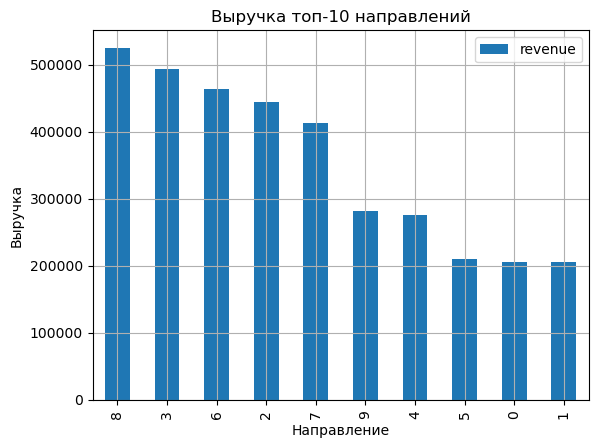

In [161]:
revenue_vvl.plot(kind='bar')
plt.title('Выручка топ-10 направлений')
plt.xlabel('Направление')
plt.ylabel('Выручка')
plt.grid()
plt.show()

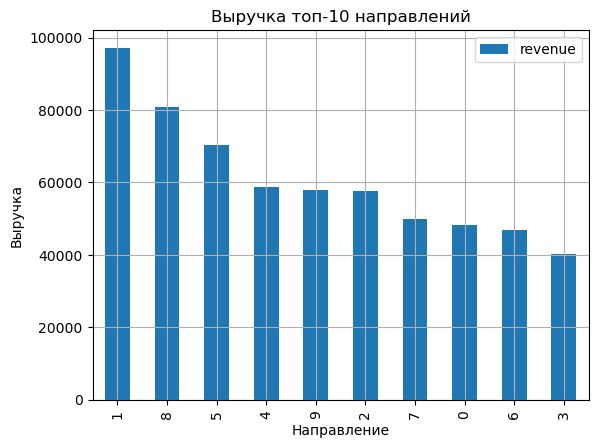

In [162]:
revenue_mvl.plot(kind='bar')
plt.title('Выручка топ-10 направлений')
plt.xlabel('Направление')
plt.ylabel('Выручка')
plt.grid()
plt.show()

***ВЫВОД:*** **Мы посмотрели топ-10 популярный направлений по ВВЛ и МВЛ. Топ-1 по ВВЛ это Сочи-Москва, а по МВЛ Москва-Ош. Далее мы посмотрели выручки. На первой строчке по ВВЛ осталось направление Сочи-Москва, а по МВЛ стало Худжанд-Москва. По выручке были построены графики, на которых можно заметить, что топ-1 и топ-10 сильно отличаются между собой как по ВВЛ, так и по МВЛ**

#### 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

In [165]:
data.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,season,sos,days_before_the_flight,groups
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12,Winter,2,35,14-60 дней


- Посмотрим зависимость выручки от месяца покупки билета и количества дней до полета, чтобы далее посомтреть матрицу корреляций

In [167]:
new_data.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,month,...,Altitude_y,Timezone_y,DST_y,Timezone Region_y,Type_y,Source_y,ICAO_Code,Location,ICAO_Code_icao,Location_icao
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,False,ONLINE,2021-12,...,42.0,2,N,Europe/Kaliningrad,airport,OurAirports,NaN,NaN,NaN,NaN


In [168]:
dependence_on = ['revenue_amount', 'sos', 'days_before_the_flight']
corr_matrix = data[dependence_on].corr()

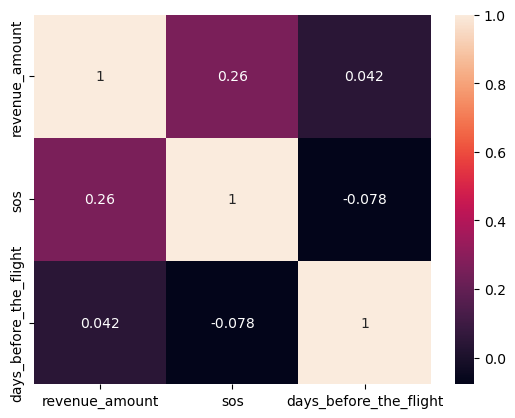

In [169]:
sns.heatmap(corr_matrix, annot=True)
plt.show()

***ВЫВОД:***
- Коэф-т корреляции находится в диапазоне от -1 до 1, значения, находящиеся ближе к 1 показыают на положительную корреляцию, ближе к -1 отрицательнуюю соответственно
- Зависимость выручки от месяца: показатель 0.26 указывает на слабую положительную связь, а значит что выручка не имеет сильной зависимости от месяца покупки билетов, однако некоторые месяцы влияют на выручку больше остальных, что довольно логично. Более наглядно и понятно это показано выше
- Зависимость вырчуки от кол-ва дней до полета: показатель 0.041 еще меньше предыдущего показатели. Значит, кол-во дней до полете почти не имеет никакого влияния на выручку. Более наглядно это можно увидеть в задании 3.4. Выручки в разных группах действительно очень близки по значениям